# The gene pair inspection

Download the precalculated gene co-occurrence (GCO) results "gene_pair.h5ad" via google drive: https://drive.google.com/drive/folders/12-vuL-gx_wKiLcZlT_ie_mfZEwiNzeND
loading the data

In [2]:
import scanpy as sc
import numpy as np
import matplotlib.pyplot as plt
# Correct and verified path to the file
# Getting the 48 Xenium slides from the David dataset
output_h5ad_path = "/scratch/project_465001820/Spatialformer/data/gene_pair.h5ad"
# Load the AnnData object from the .h5ad file
adata = sc.read_h5ad(output_h5ad_path)


In [3]:
adata.X

<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 44607258 stored elements and shape (892167, 72266)>

In [4]:
adata.obs

,Niche_Annotations,Annotations
VUILD107MF_aaaabokj-1,T2,B cells
VUILD107MF_aaaabpfm-1,T2,T-cells
VUILD107MF_aaaabpgd-1,T2,B cells
VUILD107MF_aaaabojm-1,T5,Macrophages
VUILD107MF_aaaabkng-1,T9,Fibroblasts
...,...,...
VUHD113_aaaabfjf-1,T4,SMCs
VUHD113_aaaabfji-1,T9,Fibroblasts
VUHD113_aaaabfjh-1,T4,T-cells
VUHD113_aaaabcnd-1,T4,Alveolar FBs


Assign the batch information to the cell meta data

In [5]:
adata.obs["Batch"] = adata.obs.index.map(lambda x: x.split("_")[0])

In [6]:
adata.obs["Batch"]

VUILD107MF_aaaabokj-1    VUILD107MF
VUILD107MF_aaaabpfm-1    VUILD107MF
VUILD107MF_aaaabpgd-1    VUILD107MF
VUILD107MF_aaaabojm-1    VUILD107MF
VUILD107MF_aaaabkng-1    VUILD107MF
                            ...    
VUHD113_aaaabfjf-1          VUHD113
VUHD113_aaaabfji-1          VUHD113
VUHD113_aaaabfjh-1          VUHD113
VUHD113_aaaabcnd-1          VUHD113
VUHD113_aaaabfik-1          VUHD113
Name: Batch, Length: 892167, dtype: object

Calculating the quality score

In [7]:
sc.pp.calculate_qc_metrics(
    adata, inplace=True, log1p=True
)

/scratch/project_465001820/miniconda3/envs/spatialformer_flash_attn/lib/python3.10/site-packages/scanpy/plotting/_anndata.py:793: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  g = sns.catplot(


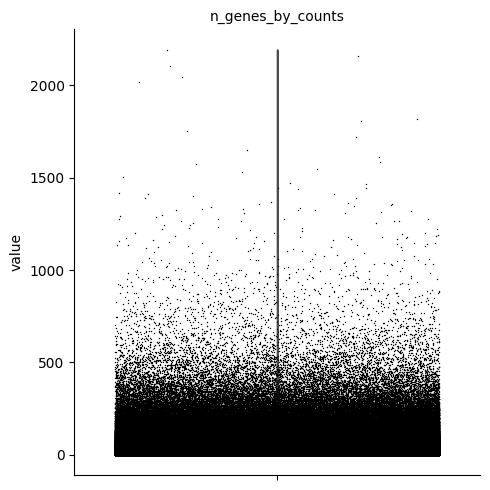

In [10]:
ax = sc.pl.violin(
    adata,
    ["n_genes_by_counts"],
    jitter=0.4,
    multi_panel=True,
    palette=["blue"],
    show=False
)

# Access the current figure
fig = plt.gcf()
ax = plt.gca()  # Get the current axes
# # Add more padding between the annotations and the figure
plt.tight_layout()
# # Show and save the modified plot
plt.show()
# Save the figure using matplotlib's savefig
fig.savefig("/scratch/project_465001820/Spatialformer/data/Figures/n_genes_by_counts_violin.png", dpi=300, bbox_inches='tight', format='png')

# Close the figure to free up memory, especially in scripts
plt.close(fig)

Normalization

In [4]:
# Saving count data
# adata.layers["counts"] = adata.X.copy()
# Normalizing to median total counts
# sc.pp.normalize_total(adata)
# Logarithmize the data
# sc.pp.log1p(adata)

Get highvariale genes

In [11]:
sc.pp.highly_variable_genes(adata, n_top_genes=2000)

/scratch/project_465001820/miniconda3/envs/spatialformer_flash_attn/lib/python3.10/site-packages/scanpy/preprocessing/_highly_variable_genes.py:226: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  disp_grouped = df.groupby("mean_bin")["dispersions"]


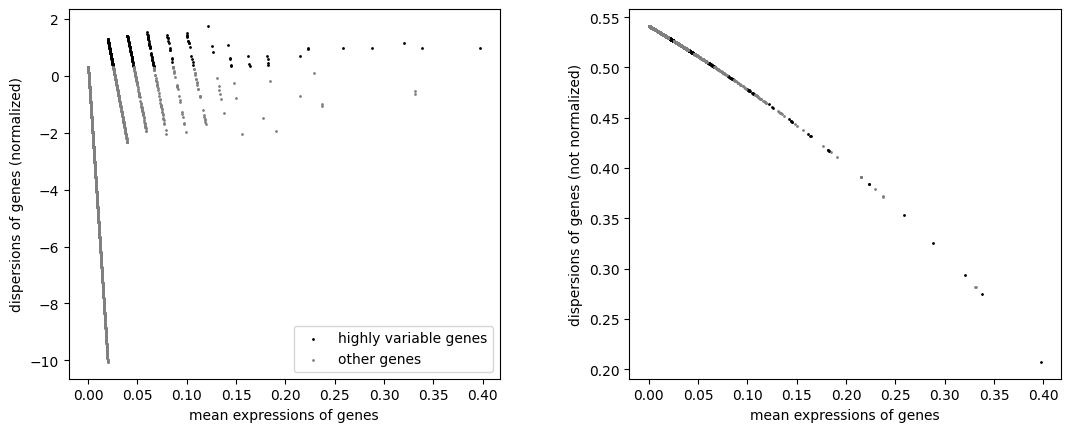

In [12]:
sc.pl.highly_variable_genes(adata)

Dimension reduction of the features

In [13]:
if not np.issubdtype(adata.X.dtype, np.floating):
    adata.X = adata.X.astype(np.float64)  # Convert to float
sc.tl.pca(adata)

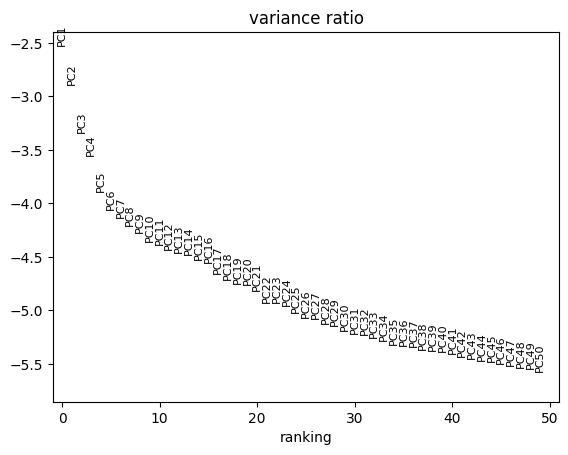

In [14]:
sc.pl.pca_variance_ratio(adata, n_pcs=50, log=True)

Subsetting the data according to the annotations

In [15]:
# Define the fraction of samples to keep from each category
frac_to_keep = 0.1
print("subsetting")
# Group by 'Annotations' and sample the desired fraction from each category
sampled_indices = (adata.obs.groupby("Annotations")
                   .apply(lambda x: x.sample(frac=frac_to_keep, random_state=42))
                   .index.get_level_values(1))

# Create a subset AnnData object using the sampled indices
subann_adata = adata[sampled_indices].copy()

subsetting


/tmp/ipykernel_27922/2053293501.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  sampled_indices = (adata.obs.groupby("Annotations")
/tmp/ipykernel_27922/2053293501.py:6: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(frac=frac_to_keep, random_state=42))


In [16]:
subset_batch_indix = np.where(adata.obs["Batch"].isin(["THD0008"]))
subann_adata = adata[subset_batch_indix].copy()

In [17]:
subann_adata.obs

,Niche_Annotations,Annotations,Batch,n_genes_by_counts,log1p_n_genes_by_counts,total_counts,log1p_total_counts,pct_counts_in_top_50_genes,pct_counts_in_top_100_genes,pct_counts_in_top_200_genes,pct_counts_in_top_500_genes
THD0008_aaaaccbc-1,T5,Macrophages,THD0008,31,3.465736,31,3.465736,100.000000,100.000000,100.0,100.0
THD0008_aaaacael-1,T5,Macrophages,THD0008,9,2.302585,9,2.302585,100.000000,100.000000,100.0,100.0
THD0008_aaababop-1,T12,Alveolar FBs,THD0008,29,3.401197,29,3.401197,100.000000,100.000000,100.0,100.0
THD0008_aaabamch-1,T2,T-cells,THD0008,102,4.634729,102,4.634729,49.019608,98.039216,100.0,100.0
THD0008_aaabacej-1,T5,Interstitial Macrophages,THD0008,21,3.091042,21,3.091042,100.000000,100.000000,100.0,100.0
...,...,...,...,...,...,...,...,...,...,...,...
THD0008_aaabacfn-1,T9,gCap,THD0008,87,4.477337,87,4.477337,57.471264,100.000000,100.0,100.0
THD0008_aaabahec-1,T9,Fibroblasts,THD0008,15,2.772589,15,2.772589,100.000000,100.000000,100.0,100.0
THD0008_aaabahha-1,T2,T-cells,THD0008,18,2.944439,18,2.944439,100.000000,100.000000,100.0,100.0
THD0008_aaabaagh-1,T9,Fibroblasts,THD0008,29,3.401197,29,3.401197,100.000000,100.000000,100.0,100.0


In [18]:
# Subset the data by these highly variable genes
adata_hvg = adata[:, adata.var.highly_variable].copy()
subann_adata_hvg = subann_adata[:, subann_adata.var.highly_variable].copy()

plotting UMAP

/scratch/project_465001820/miniconda3/envs/spatialformer_flash_attn/lib/python3.10/site-packages/scanpy/preprocessing/_normalization.py:196: UserWarning: Some cells have zero counts
  warn(UserWarning('Some cells have zero counts'))
/scratch/project_465001820/miniconda3/envs/spatialformer_flash_attn/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/scratch/project_465001820/miniconda3/envs/spatialformer_flash_attn/lib/python3.10/site-packages/umap/spectral.py:550: UserWarning: Spectral initialisation failed! The eigenvector solver
failed. This is likely due to too small an eigengap. Consider
adding some noise or jitter to your data.

Falling back to random initialisation!
  warn(


/scratch/project_465001820/miniconda3/envs/spatialformer_flash_attn/lib/python3.10/site-packages/scanpy/plotting/_tools/scatterplots.py:1234: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
/scratch/project_465001820/miniconda3/envs/spatialformer_flash_attn/lib/python3.10/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(
/scratch/project_465001820/miniconda3/envs/spatialformer_flash_attn/lib/python3.10/site-packages/scanpy/plotting/_tools/scatterplots.py:1234: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set

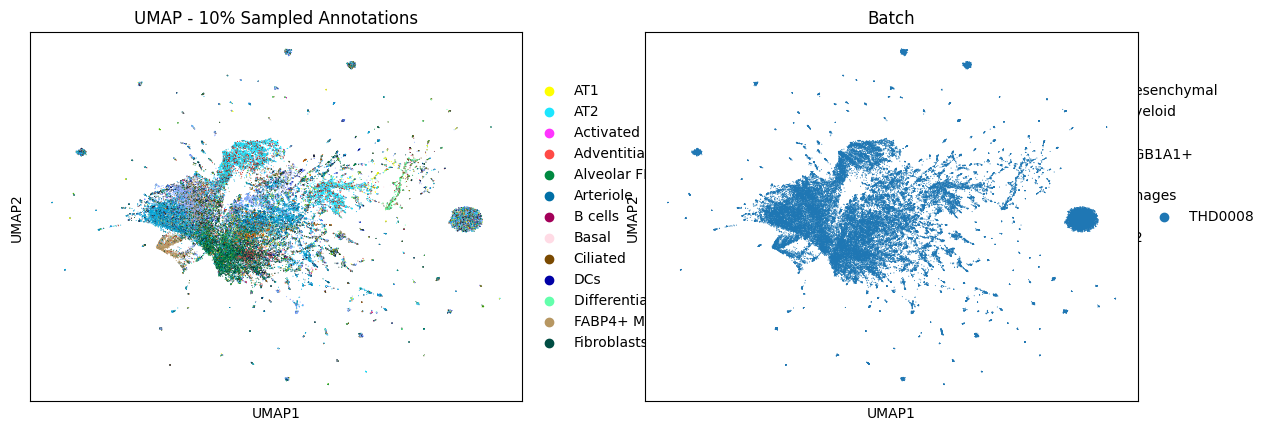

In [19]:
# Assume 'adata' is your original AnnData object
sc.pp.normalize_total(subann_adata_hvg, target_sum=1e4)
sc.pp.log1p(subann_adata_hvg)
# Perform PCA to reduce dimensionality
sc.pp.pca(subann_adata_hvg, n_comps=40)  # You can adjust the number of components
# Compute nearest neighbors using the PCA representation
sc.pp.neighbors(subann_adata_hvg, use_rep='X_pca')
# Run UMAP on the subset data
sc.tl.umap(subann_adata_hvg, spread =2, min_dist = 0.5, random_state=42)
# Plot the UMAP
sc.pl.umap(subann_adata_hvg, color=['Annotations', "Batch"], title="UMAP - 10% Sampled Annotations")

In [12]:
# Using the igraph implementation and a fixed number of iterations can be significantly faster, especially for larger datasets
# sc.tl.leiden(subann_adata_hvg, resolution=1.0, random_state=42, n_iterations=2)
# sc.pl.umap(subann_adata_hvg, color=["leiden"])

Calculating the differential expression genes

In [21]:
import pandas as pd
# Obtain cluster-specific differentially expressed genes
sc.tl.rank_genes_groups(adata_hvg, groupby="Annotations", method="wilcoxon")
# Save the DataFrame to a CSV file
# List to store DataFrames for each group
df_list = []

# Retrieve the list of groups
groups = adata_hvg.uns['rank_genes_groups']['names'].dtype.names

# Iterate through each group and compile the results
for group in groups:
    # Extract the DataFrame for the current group
    ranked_genes_df = sc.get.rank_genes_groups_df(adata_hvg, group=group)
    
    # Add a new column to indicate the group
    ranked_genes_df['group'] = group
    
    # Append the DataFrame to the list
    df_list.append(ranked_genes_df)

# Concatenate all group DataFrames into a single DataFrame
all_groups_df = pd.concat(df_list, ignore_index=True)

# Save the combined DataFrame to a CSV file
output_csv_path = "/scratch/project_465001820/Spatialformer/downstream/GCO_analysis/data/ranked_genes_all_groups.csv"
all_groups_df.to_csv(output_csv_path, index=False)

print(f"Complete differential expression results saved to {output_csv_path}")


/scratch/project_465001820/miniconda3/envs/spatialformer_flash_attn/lib/python3.10/site-packages/numpy/core/fromnumeric.py:86: FutureWarning: The behavior of DataFrame.sum with axis=None is deprecated, in a future version this will reduce over both axes and return a scalar. To retain the old behavior, pass axis=0 (or do not pass axis)
  return reduction(axis=axis, out=out, **passkwargs)
/scratch/project_465001820/miniconda3/envs/spatialformer_flash_attn/lib/python3.10/site-packages/scanpy/tools/_rank_genes_groups.py:396: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  self.stats[group_name, 'names'] = self.var_names[global_indices]
/scratch/project_465001820/miniconda3/envs/spatialformer_flash_attn/lib/python3.10/site-packages/scanpy/tools/_rank_genes_groups.

Complete differential expression results saved to /scratch/project_465001820/Spatialformer/downstream/GCO_analysis/data/ranked_genes_all_groups.csv


In [26]:
ranked_genes_df

,names,scores,logfoldchanges,pvals,pvals_adj,group
0,"('HERPUD1', 'VIM')",15.428482,3.008823,1.053184e-53,1.026749e-49,pDCs
1,"('VIM', 'JCHAIN')",13.751184,3.215967,5.010251e-43,2.442247e-39,pDCs
2,"('JCHAIN', 'VIM')",12.636822,2.440066,1.322946e-36,4.299133e-33,pDCs
3,"('HERPUD1', 'HLA-DRA')",10.550750,3.412130,5.039311e-26,1.228206e-22,pDCs
4,"('HERPUD1', 'PTGDS')",10.195498,4.300990,2.076761e-24,4.049268e-21,pDCs
...,...,...,...,...,...,...
9744,"('COL1A2', 'COL3A1')",-2.972081,-0.798684,2.957887e-03,9.999533e-01,pDCs
9745,"('LUM', 'COL3A1')",-3.267636,-1.157364,1.084499e-03,4.596859e-01,pDCs
9746,"('CCN2', 'VIM')",-3.844529,-1.852204,1.207840e-04,5.607255e-02,pDCs
9747,"('FN1', 'VIM')",-5.400660,-0.731273,6.639628e-08,4.045608e-05,pDCs


In [25]:
len(adata_hvg.uns['rank_genes_groups']["names"].dtype.names)

40

i want to make a heatmap of all these filtered gene pairs

In [27]:
#selecting the top 10 gene pairs for cell types according to logfoldchanges
# Assuming 'logfoldchanges' column is available and you want to sort by it
# ranked_genes_df_sorted = ranked_genes_df.sort_values(by='logfoldchanges', ascending=False)
# Retrieve the list of groups (clusters) analyzed
groups = adata_hvg.uns['rank_genes_groups']['names'].dtype.names
# Create a DataFrame to store top markers for all groups
top_markers_all_clusters = pd.DataFrame()
# Iterate over each group/cluster
for group in groups:
    # Extract ranked genes for the current group
    ranked_genes_df = sc.get.rank_genes_groups_df(adata_hvg, group=group)
    positive_logfc_df = ranked_genes_df[(ranked_genes_df['logfoldchanges'] > 0) & (ranked_genes_df['pvals_adj'] < 0.05)]
    
    # Sort by adjusted p-value ('pvals_adj') and log fold changes ('logfoldchanges')
    ranked_genes_df_sorted = positive_logfc_df.sort_values(by=['pvals_adj', 'logfoldchanges'], ascending=[True, False])
    
    # Select top 10 genes
    top_10_markers_df = ranked_genes_df_sorted.head(5)
    
    # Add a column for the cluster/group for clarity
    top_10_markers_df['cluster'] = group
    
    # Append to the main DataFrame
    top_markers_all_clusters = pd.concat([top_markers_all_clusters, top_10_markers_df], ignore_index=True)



/scratch/project_465001820/miniconda3/envs/spatialformer_flash_attn/lib/python3.10/site-packages/scanpy/get/get.py:69: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  d = d.stack(level=1).reset_index()
/tmp/ipykernel_27922/4172682264.py:21: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  top_10_markers_df['cluster'] = group
/scratch/project_465001820/miniconda3/envs/spatialformer_flash_attn/lib/python3.10/site-packages/scanpy/get/get.py:69: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future versi

In [28]:
top_markers_all_clusters

,names,scores,logfoldchanges,pvals,pvals_adj,cluster
0,"('EPCAM', 'ICAM1')",27.602551,3.898141,1.036957e-167,2.527324e-164,AT1
1,"('CEACAM6', 'ICAM1')",24.896687,3.907086,8.081152e-137,1.313053e-133,AT1
2,"('FN1', 'ICAM1')",23.938461,3.589346,1.218622e-126,1.485043e-123,AT1
3,"('ITGB1', 'ICAM1')",22.493736,3.460304,4.780064e-112,5.177872e-109,AT1
4,"('NAPSA', 'ICAM1')",18.092785,3.264076,3.632617e-73,2.529599e-70,AT1
...,...,...,...,...,...,...
187,"('HERPUD1', 'VIM')",15.428482,3.008823,1.053184e-53,1.026749e-49,pDCs
188,"('VIM', 'JCHAIN')",13.751184,3.215967,5.010251e-43,2.442247e-39,pDCs
189,"('JCHAIN', 'VIM')",12.636822,2.440066,1.322946e-36,4.299133e-33,pDCs
190,"('HERPUD1', 'HLA-DRA')",10.550750,3.412130,5.039311e-26,1.228206e-22,pDCs


In [29]:
#getting the dict of the group: markers
# Create a dictionary where each group is a key, and values are lists of names
marker_pairs_dict = top_markers_all_clusters.groupby("cluster")["names"].apply(list).to_dict()

In [30]:
marker_pairs_dict

{'AT1': ["('EPCAM', 'ICAM1')",
  "('CEACAM6', 'ICAM1')",
  "('FN1', 'ICAM1')",
  "('ITGB1', 'ICAM1')",
  "('NAPSA', 'ICAM1')"],
 'AT2': ["('LAMP3', 'SFTPD')",
  "('DUOX1', 'SFTPC')",
  "('LAMP3', 'NAPSA')",
  "('MGST1', 'SFTPD')",
  "('LAMP3', 'CD44')"],
 'Activated FBs': ["('VIM', 'COL1A1')",
  "('POSTN', 'FN1')",
  "('MEG3', 'COL3A1')",
  "('MEG3', 'COL1A2')",
  "('LUM', 'COL1A1')"],
 'Adventitial FBs': ["('LUM', 'DCN')",
  "('COL1A2', 'SFRP2')",
  "('SPARCL1', 'SFRP2')",
  "('SPARCL1', 'DCN')",
  "('PTGDS', 'SFRP2')"],
 'Alveolar FBs': ["('SFTPC', 'VIM')",
  "('COL1A2', 'FN1')",
  "('COL1A2', 'COL3A1')",
  "('FN1', 'VIM')",
  "('PTGDS', 'FN1')"],
 'Arteriole': ["('SPARCL1', 'VIM')",
  "('VIM', 'EPAS1')",
  "('ITGB1', 'EPAS1')",
  "('PECAM1', 'FN1')",
  "('FN1', 'VIM')"],
 'B cells': ["('VIM', 'HLA-DRA')",
  "('CXCR4', 'VIM')",
  "('HLA-DRA', 'VIM')",
  "('PTPRC', 'HLA-DRA')",
  "('JCHAIN', 'HLA-DRA')"],
 'Basal': ["('SCGB3A2', 'SCGB1A1')",
  "('HLA-DRA', 'SCGB1A1')",
  "('PDIA3', 'S

categories: AT1, AT2, Activated FBs, etc.
var_group_labels: AT1, AT2, Activated FBs, etc.


/scratch/project_465001820/miniconda3/envs/spatialformer_flash_attn/lib/python3.10/site-packages/scanpy/tools/_dendrogram.py:135: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mean_df = rep_df.groupby(level=0).mean()


/tmp/ipykernel_27922/210429359.py:24: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


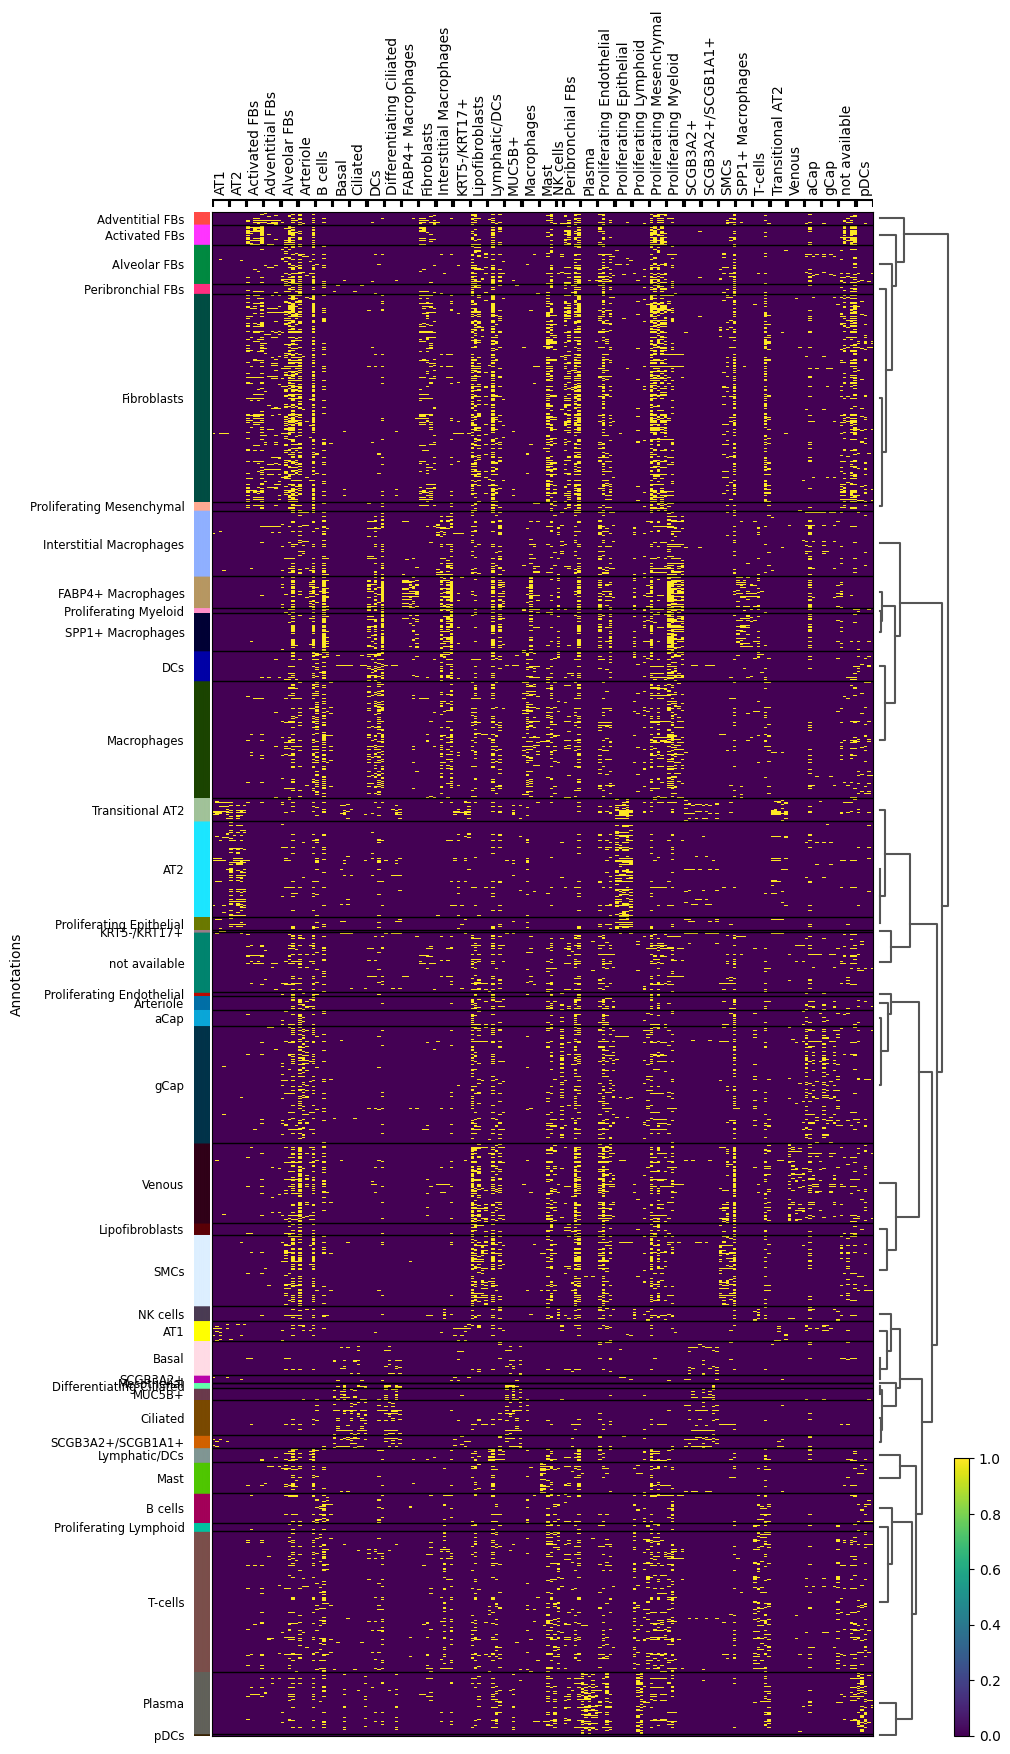

In [32]:
#define the marker gene 
#Here i select the top 5 gene pair markers
# Reorder columns in adata by specified 'ordered_labels'
# adata_hvg = adata_hvg[:, np.array([marker for marker in marker_pairs_dict])]
adata_sorted = adata_hvg[adata_hvg.obs.sort_values("Annotations").index].copy()


ax = sc.pl.heatmap(
    adata_sorted,
    marker_pairs_dict, 
    groupby="Annotations", 
    cmap="viridis", 
    dendrogram=True,
    figsize=(10, 20), 
    swap_axes=False,
    show=False
)
# Customize the heatmap aesthetics with matplotlib after plotting
fig = plt.gcf()  # Get the current figure from the plot
ax = plt.gca()  # Get the current axes

# # Add more padding between the annotations and the figure
plt.tight_layout()

# # Show and save the modified plot
plt.show()

# Optional: Save the arranged heatmap
fig.savefig("/scratch/project_465001820/Spatialformer/downstream/GCO_analysis/Figures/arranged_heatmap.png", dpi=300, bbox_inches='tight')
# Close the figure to free up memory, especially in scripts
plt.close(fig)

In [ ]:
adata_hvg.obs

,Niche_Annotations,Annotations,n_genes_by_counts,log1p_n_genes_by_counts,total_counts,log1p_total_counts,pct_counts_in_top_50_genes,pct_counts_in_top_100_genes,pct_counts_in_top_200_genes,pct_counts_in_top_500_genes
cell_0,T2,B cells,9,2.302585,9,2.302585,100.0,100.0,100.0,100.0
cell_1,T2,T-cells,7,2.079442,7,2.079442,100.0,100.0,100.0,100.0
cell_2,T2,B cells,2,1.098612,2,1.098612,100.0,100.0,100.0,100.0
cell_3,T5,Macrophages,35,3.583519,35,3.583519,100.0,100.0,100.0,100.0
cell_4,T9,Fibroblasts,36,3.610918,36,3.610918,100.0,100.0,100.0,100.0
...,...,...,...,...,...,...,...,...,...,...
cell_892162,T4,SMCs,4,1.609438,4,1.609438,100.0,100.0,100.0,100.0
cell_892163,T9,Fibroblasts,1,0.693147,1,0.693147,100.0,100.0,100.0,100.0
cell_892164,T4,T-cells,11,2.484907,11,2.484907,100.0,100.0,100.0,100.0
cell_892165,T4,Alveolar FBs,24,3.218876,24,3.218876,100.0,100.0,100.0,100.0


In [33]:
import scanpy as sc
# markers = ["('JCHAIN', 'HLA-DRA')", "('STAT1', 'HLA-DRA')", "('VIM', 'HLA-DRA')"]
cluster_list = ["Basal", "Transitional AT2", "AT2", "AT1", "Ciliated", "Differentiating Ciliated", "MUCSB+", "SCGB3A2+", "SCGB3A2+/SCGB1A1+"
                "Proliferating", "KRT5-/KRT17+", 
               ]

adata_dot = adata[adata.obs["Annotations"].isin(cluster_list),:]

# marker_cluster = ["AT2", "AT1", "Ciliated", "Differentiating Ciliated", "Basal"]
marker_cluster = cluster_list
markers = top_markers_all_clusters[top_markers_all_clusters["cluster"].isin(marker_cluster)]["names"].values

import matplotlib.pyplot as plt

# Plot without immediately saving or displaying
sc.pl.dotplot(
    adata_dot, 
    markers, 
    groupby='Annotations', 
    dendrogram=True, 
    show=False
)

# Get the current figure and save it
plt.savefig("/scratch/project_465001820/Spatialformer/downstream/GCO_analysis/Figures/pair_dotplot.png", dpi=300, bbox_inches='tight')

# Clear the plot
plt.close()



/scratch/project_465001820/miniconda3/envs/spatialformer_flash_attn/lib/python3.10/site-packages/scanpy/plotting/_dotplot.py:168: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  obs_bool.groupby(level=0).sum() / obs_bool.groupby(level=0).count()
/scratch/project_465001820/miniconda3/envs/spatialformer_flash_attn/lib/python3.10/site-packages/scanpy/plotting/_dotplot.py:178: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  dot_color_df = self.obs_tidy.groupby(level=0).mean()
/scratch/project_465001820/miniconda3/envs/spatialformer_flash_attn/lib/python3.10/site-packages/scanpy/tools/_dendrogram.py:135: FutureWarning

plot the violin plot to show the expression level of some gene pairs

In [35]:
# marker_cluster = ["AT2", "AT1", "Ciliated", "Differentiating Ciliated", "Basal"]
marker_cluster = ["Differentiating Ciliated"]
markers = top_markers_all_clusters[top_markers_all_clusters["cluster"].isin(marker_cluster)]["names"].values

for pair in markers:
    # Generate the violin plot without displaying it immediately
    sc.pl.violin(
        adata_dot, 
        pair, 
        groupby="Annotations", 
        show=False  # Prevents the plot from showing
    )
    # Rotate x-labels by 60 degrees
    plt.xticks(rotation=60)
    # Save the current figure
    plt.savefig(f"/scratch/project_465001820/Spatialformer/downstream/GCO_analysis/Figures/violin_plot_differential_ciliated_{pair}.png", dpi=300, bbox_inches='tight')

    # Clear the plot to free up memory
    plt.close()

/scratch/project_465001820/miniconda3/envs/spatialformer_flash_attn/lib/python3.10/site-packages/scanpy/plotting/_anndata.py:839: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.violinplot(
/scratch/project_465001820/miniconda3/envs/spatialformer_flash_attn/lib/python3.10/site-packages/scanpy/plotting/_anndata.py:839: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  ax = sns.violinplot(
/scratch/project_465001820/miniconda3/envs/spatialformer_flash_attn/lib/python3.10/site-packages/scanpy/plotting/_anndata.py:839: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.violinplot(
/scratch/project_465001820/miniconda3/

In [47]:
# marker_cluster = ["AT2", "AT1", "Ciliated", "Differentiating Ciliated", "Basal"]
marker_cluster = ["Differentiating Ciliated"]
markers = top_markers_all_clusters[top_markers_all_clusters["cluster"].isin(marker_cluster)]["names"].values
# Set font sizes globally BEFORE creating the plot
plt.rcParams.update({
    'font.size': 14,
    'axes.labelsize': 14,
    'axes.titlesize': 14,
    'xtick.labelsize': 14,
    'ytick.labelsize': 14,
    'legend.fontsize': 12,
    'legend.title_fontsize': 12
})

dp = sc.pl.dotplot(
    adata_dot,
    var_names=list(markers),
    groupby="Annotations",
    standard_scale="var",
    show=False,
    return_fig=True,
    figsize=(10, max(4, len(markers) * 0.25)),
    cmap='Reds'  # Red colormap
    
)

dp.style(dot_edge_lw=0.7).savefig(
    "/scratch/project_465001820/Spatialformer/downstream/GCO_analysis/Figures/dotplot_differential_ciliated.png",
    dpi=300,
    bbox_inches='tight'
)
plt.close()

# Reset to defaults
plt.rcParams.update(plt.rcParamsDefault)

/scratch/project_465001820/miniconda3/envs/spatialformer_flash_attn/lib/python3.10/site-packages/scanpy/plotting/_dotplot.py:168: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  obs_bool.groupby(level=0).sum() / obs_bool.groupby(level=0).count()
/scratch/project_465001820/miniconda3/envs/spatialformer_flash_attn/lib/python3.10/site-packages/scanpy/plotting/_dotplot.py:178: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  dot_color_df = self.obs_tidy.groupby(level=0).mean()
/scratch/project_465001820/miniconda3/envs/spatialformer_flash_attn/lib/python3.10/site-packages/scanpy/plotting/_dotplot.py:747: UserWarning: 